In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# project root
os.chdir('c:/dev/AnalystLab_Internship')

# Now use relative path from root
netflix_path = "Week_1/data/netflix_titles.csv"
retail_path = "Week_1/data/online_retail/OnlineRetail.csv"

netflix_df = pd.read_csv(netflix_path)
retail_df = pd.read_csv(retail_path, encoding='cp1252')

# Worked fine, so I commented out
# netflix_df.head(2)
# retail_df.head(2)


In [ ]:
dupne = netflix_df.duplicated().sum()
dupre = retail_df.duplicated().sum()

# dupre = 5268 duplicate records
# print(dupre)

Netflix

In [ ]:
netflix_df['date_added'] = pd.to_datetime(
    netflix_df['date_added'].str.strip(),  # Remove spaces first
    errors='coerce'
)

# Then format if you want string format
netflix_df['date_added'] = netflix_df['date_added'].dt.strftime('%Y-%m-%d')

netflix_df.head(2)

In [ ]:
print("Netflix Dataset Shape:", netflix_df.shape)
print("\nMissing Values Analysis:")
missing_counts = netflix_df.isnull().sum()
missing_pct = (missing_counts / len(netflix_df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_counts,
    'Percentage': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Percentage', ascending=False))

# Strategic handling based on business context
def clean_netflix_data(df):
    df_clean = df.copy()

    # Using 'Unknown' preserves the data for analysis without losing rows
    df_clean['director'] = df_clean['director'].fillna('Unknown')
    print("✓ Director: Filled 2,634 missing values with 'Unknown'")

    # 'Not Available' is more appropriate than 'Unknown' for cast
    df_clean['cast'] = df_clean['cast'].fillna('Not Available')
    print("✓ Cast: Filled 825 missing values with 'Not Available'")
    
    df_clean['country'] = df_clean['country'].fillna('Unknown')
    print(f"✓ Country: Filled 831 missing values with 'Unknown'")
    
    # Better to drop few rows than create incorrect dates
    df_clean = df_clean.dropna(subset=['date_added'])
    print("✓ Date Added: Dropped 10 rows with missing dates")
    
    # Very few missing, mode imputation is safe
    most_common_rating = df_clean['rating'].mode()[0]
    df_clean['rating'] = df_clean['rating'].fillna(most_common_rating)
    print(f"✓ Rating: Filled 4 missing values with '{most_common_rating}'")

    # Only 3 missing, safer to drop than impute incorrectly
    df_clean = df_clean.dropna(subset=['duration'])
    print("✓ Duration: Dropped 3 rows with missing duration")
    
    return df_clean

# Clean the data
netflix_df_clean = clean_netflix_data(netflix_df)

# Verify cleaning
print("\n" + "="*50)
print("CLEANING SUMMARY")
print("="*50)
print(f"Original shape: {netflix_df.shape}")
print(f"Cleaned shape: {netflix_df_clean.shape}")
print(f"Total rows removed: {netflix_df.shape[0] - netflix_df_clean.shape[0]}")
print(f"Remaining missing values: {netflix_df_clean.isnull().sum().sum()}")

# Quality check - show sample of cleaned columns
print("\nSample of cleaned data:")
print(netflix_df_clean[['director', 'cast', 'country', 'rating']].head(3))

In [32]:
# Clean and convert date_added to datetime
netflix_df['date_added'] = pd.to_datetime(netflix_df['date_added'].str.strip(), errors='coerce')
netflix_df['year_added'] = netflix_df['date_added'].dt.year

1. Movies vs TV Shows distribution


type
Movie      6131
TV Show    2676
Name: count, dtype: int64


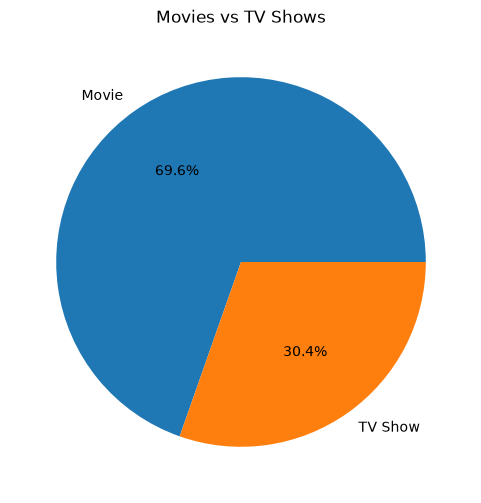

In [33]:
type_counts = netflix_df['type'].value_counts()
print(type_counts)

import matplotlib.pyplot as plt
type_counts.plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title('Movies vs TV Shows')
plt.ylabel('')
plt.show()

2. Content added by year


year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
Name: count, dtype: int64


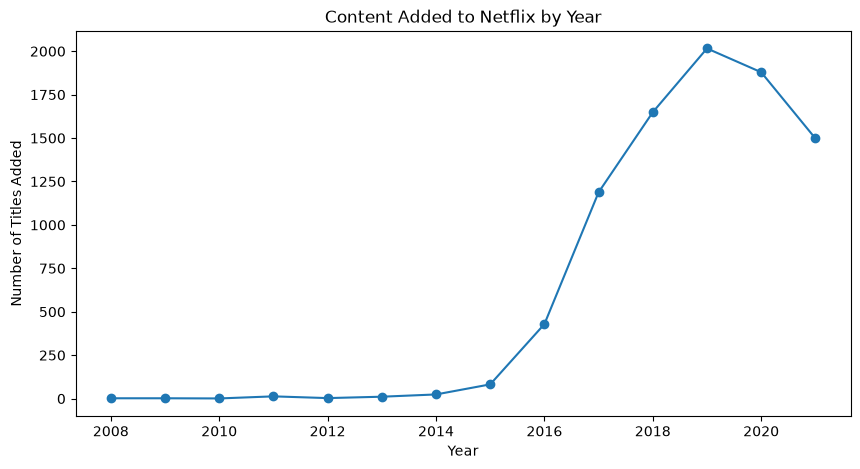

In [34]:
content_by_year = netflix_df['year_added'].value_counts().sort_index()
print(content_by_year)

content_by_year.plot(kind='line', marker='o', figsize=(10,5))
plt.title('Content Added to Netflix by Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.show()

3. Top content-producing countries


country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64


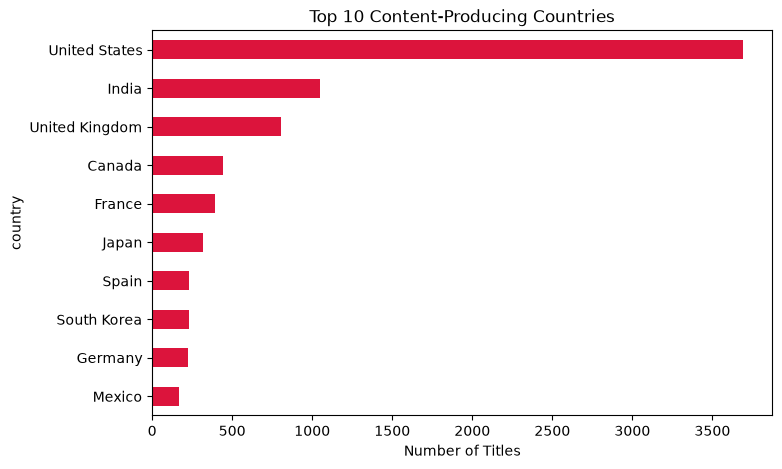

In [35]:
top_countries = (
    netflix_df['country']
    .dropna()
    .str.split(', ')
    .explode()
    .value_counts()
    .head(10)
)
print(top_countries)

top_countries.plot(kind='barh', figsize=(8,5), color='crimson')
plt.title('Top 10 Content-Producing Countries')
plt.xlabel('Number of Titles')
plt.gca().invert_yaxis()
plt.show()

4. Most common ratings


rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64


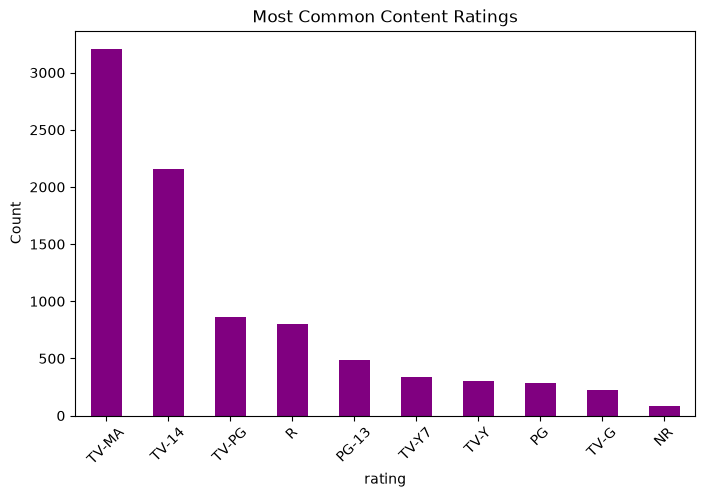

In [36]:
rating_counts = netflix_df['rating'].value_counts().head(10)
print(rating_counts)

rating_counts.plot(kind='bar', figsize=(8,5), color='purple')
plt.title('Most Common Content Ratings')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

5. Most common genres/categories


listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


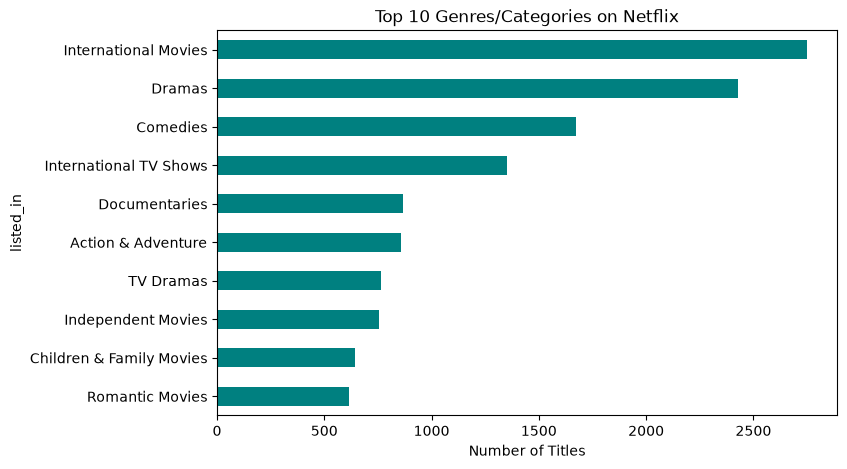

In [37]:
top_genres = (
    netflix_df['listed_in']
    .dropna()
    .str.split(', ')
    .explode()
    .value_counts()
    .head(10)
)
print(top_genres)

top_genres.plot(kind='barh', figsize=(8,5), color='teal')
plt.title('Top 10 Genres/Categories on Netflix')
plt.xlabel('Number of Titles')
plt.gca().invert_yaxis()
plt.show()

Retail

In [38]:
print("="*80)
print("RETAIL DATA CLEANING - COMPLETE PIPELINE")
print("="*80)
print(f"Original dataset shape: {retail_df.shape}")
print(f"Columns: {retail_df.columns.tolist()}")
print("\n" + "="*80)

# ============================================
# 1. MISSING VALUES ANALYSIS & HANDLING
# ============================================

print("\n" + "="*80)
print("1. MISSING VALUES ANALYSIS")
print("="*80)

# Identify columns with missing values
columns_with_null = retail_df.columns[retail_df.isnull().any()].tolist()
print(f"\n📊 Columns with missing values: {columns_with_null}")

# Show number of missing values per column
missing_counts = retail_df.isnull().sum()
print(f"\n📊 Missing values per column:")
print(missing_counts[missing_counts > 0])

# Show percentage of missing values
missing_percentages = (retail_df.isnull().sum() / len(retail_df)) * 100
print(f"\n📊 Percentage of missing values:")
print(missing_percentages[missing_percentages > 0].sort_values(ascending=False))

# ============================================
# HANDLE MISSING VALUES
# ============================================

print("\n" + "="*80)
print("2. HANDLING MISSING VALUES")
print("="*80)

# Create a clean copy
retail_df_clean = retail_df.copy()

# A) CustomerID - Strategic handling
print("\n🔍 CustomerID Analysis:")
print(f"   - Missing values: {retail_df['CustomerID'].isna().sum():,} ({missing_percentages['CustomerID']:.2f}%)")

# Option 1: Create Customer Analytics version (keep only rows with CustomerID)
retail_customer_analytics = retail_df_clean.dropna(subset=['CustomerID']).copy()
print(f"   ✅ Version A (Customer Analytics): {len(retail_customer_analytics):,} rows ({len(retail_customer_analytics)/len(retail_df)*100:.1f}% kept)")

# Option 2: Create Sales Analytics version (fill missing with 0)
retail_sales_analytics = retail_df_clean.copy()
retail_sales_analytics['CustomerID'] = retail_sales_analytics['CustomerID'].fillna(0)
print(f"   ✅ Version B (Sales Analytics): {len(retail_sales_analytics):,} rows (100% kept, missing filled with 0)")

# Explanation for CustomerID handling
print(f"\n   💡 WHY: CustomerID is critical for customer analytics (RFM analysis, segmentation).")
print(f"      However, for sales/transaction analysis, we want to keep all transactions.")
print(f"      Therefore, we created two versions for different analysis purposes.")

# B) Description - Fill with placeholder
description_missing = retail_df['Description'].isna().sum()
retail_df_clean['Description'] = retail_df_clean['Description'].fillna('Unknown')
print(f"\n🔍 Description Analysis:")
print(f"   - Missing values: {description_missing:,} ({missing_percentages['Description']:.2f}%)")
print(f"   ✅ Filled with 'Unknown'")
print(f"   💡 WHY: Only 0.27% missing, dropping would lose valid transaction data.")
print(f"      'Unknown' clearly indicates missing product description.")

# ============================================
# 3. DUPLICATE RECORDS
# ============================================

print("\n" + "="*80)
print("3. DUPLICATE RECORDS")
print("="*80)

# Identify duplicate rows
duplicate_count = retail_df_clean.duplicated().sum()
print(f"\n📊 Duplicate rows found: {duplicate_count:,}")

# Show sample of duplicates if any
if duplicate_count > 0:
    duplicate_samples = retail_df_clean[retail_df_clean.duplicated(keep=False)].head(5)
    print(f"\n📋 Sample of duplicate rows:")
    print(duplicate_samples[['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'CustomerID']])

# Remove duplicates
retail_df_clean = retail_df_clean.drop_duplicates()
print(f"\n✅ Removed {duplicate_count:,} duplicate records")
print(f"   New shape: {retail_df_clean.shape}")
print(f"   💡 WHY: Duplicates can skew analysis results (overcounting sales, incorrect totals).")
print(f"      Removed all exact duplicate rows while keeping first occurrence.")

# ============================================
# 4. STANDARDIZATION
# ============================================

print("\n" + "="*80)
print("4. STANDARDIZATION")
print("="*80)

# A) Date Format Standardization
print("\n📅 Date Format Standardization:")
print(f"   Original format: {retail_df_clean['InvoiceDate'].iloc[0]} (mixed format)")

# Convert to datetime
retail_df_clean['InvoiceDate'] = pd.to_datetime(
    retail_df_clean['InvoiceDate'],
    format='%m/%d/%Y %H:%M',  # 12/9/2011 12:50
    errors='coerce'
)

# Extract date components for analysis
retail_df_clean['InvoiceYear'] = retail_df_clean['InvoiceDate'].dt.year
retail_df_clean['InvoiceMonth'] = retail_df_clean['InvoiceDate'].dt.month
retail_df_clean['InvoiceDay'] = retail_df_clean['InvoiceDate'].dt.day
retail_df_clean['InvoiceHour'] = retail_df_clean['InvoiceDate'].dt.hour

print(f"   ✅ Converted to datetime format: {retail_df_clean['InvoiceDate'].dtype}")
print(f"   ✅ Extracted Year, Month, Day, Hour components")
print(f"   💡 WHY: Standard dates enable time-series analysis, trend analysis, and proper sorting.")

# B) Text Formatting Standardization
print("\n📝 Text Formatting Standardization:")

# Description - Strip whitespace and standardize case
retail_df_clean['Description'] = retail_df_clean['Description'].str.strip().str.upper()
print(f"   ✅ Description: Stripped whitespace and converted to UPPERCASE")

# Country - Strip whitespace and standardize
retail_df_clean['Country'] = retail_df_clean['Country'].str.strip().str.title()
print(f"   ✅ Country: Stripped whitespace and converted to Title Case")

# StockCode - Strip whitespace
retail_df_clean['StockCode'] = retail_df_clean['StockCode'].astype(str).str.strip()
print(f"   ✅ StockCode: Stripped whitespace")

# InvoiceNo - Strip whitespace
retail_df_clean['InvoiceNo'] = retail_df_clean['InvoiceNo'].astype(str).str.strip()
print(f"   💡 WHY: Consistent text formatting prevents mismatches (e.g., 'UK' vs 'uk' vs 'Uk').")

# C) Column Name Standardization
print("\n📊 Column Name Standardization:")

# Check current column names
print(f"   Current columns: {retail_df_clean.columns.tolist()}")

# Rename columns to snake_case for consistency
retail_df_clean.rename(columns={
    'InvoiceNo': 'invoice_no',
    'StockCode': 'stock_code',
    'Description': 'description',
    'Quantity': 'quantity',
    'InvoiceDate': 'invoice_date',
    'UnitPrice': 'unit_price',
    'CustomerID': 'customer_id',
    'Country': 'country'
}, inplace=True)

print(f"   ✅ Renamed columns to snake_case")
print(f"   New columns: {retail_df_clean.columns.tolist()}")
print(f"   💡 WHY: Consistent naming convention improves code readability and maintainability.")

# D) Data Type Standardization
print("\n💾 Data Type Standardization:")

# Convert to appropriate types
retail_df_clean['customer_id'] = retail_df_clean['customer_id'].astype('float64')  # Keep as float for NaN handling
retail_df_clean['quantity'] = retail_df_clean['quantity'].astype('int64')
retail_df_clean['unit_price'] = retail_df_clean['unit_price'].astype('float64')

# Convert categorical columns
categorical_cols = ['stock_code', 'description', 'country']
for col in categorical_cols:
    if col in retail_df_clean.columns:
        retail_df_clean[col] = retail_df_clean[col].astype('category')

print(f"   ✅ Converted {len(categorical_cols)} columns to categorical:")
for col in categorical_cols:
    print(f"      - {col}: {retail_df_clean[col].dtype}")

print(f"   ✅ Converted quantity to int64, unit_price to float64")
print(f"   💡 WHY: Proper data types reduce memory usage and improve performance.")

# ============================================
# 5. DATA VALIDATION
# ============================================

print("\n" + "="*80)
print("5. DATA VALIDATION")
print("="*80)

# A) Invalid Values - Quantity
print("\n🔍 Quantity Validation:")

# Check for negative quantities (returns)
negative_quantity = retail_df_clean[retail_df_clean['quantity'] < 0]
print(f"   - Negative quantities (returns): {len(negative_quantity):,} rows")

# Check for zero quantity
zero_quantity = retail_df_clean[retail_df_clean['quantity'] == 0]
print(f"   - Zero quantity: {len(zero_quantity):,} rows")

# Handle invalid quantities
print(f"\n   ✅ Action: Keeping negative quantities (valid returns)")
print(f"   ✅ Action: Removing rows with zero quantity")
retail_df_clean = retail_df_clean[retail_df_clean['quantity'] != 0]
print(f"   💡 WHY: Negative quantities represent valid returns/cancellations.")
print(f"      Zero quantity has no business meaning and should be removed.")

# B) Invalid Values - UnitPrice
print("\n🔍 UnitPrice Validation:")

# Check for invalid prices (<= 0)
invalid_price = retail_df_clean[retail_df_clean['unit_price'] <= 0]
print(f"   - Invalid unit prices (<= 0): {len(invalid_price):,} rows")

# Handle invalid prices
if len(invalid_price) > 0:
    # Option 1: Remove invalid prices
    retail_df_clean = retail_df_clean[retail_df_clean['unit_price'] > 0]
    print(f"   ✅ Removed {len(invalid_price):,} rows with invalid unit prices")

# Check for outliers (extremely high prices)
price_99 = retail_df_clean['unit_price'].quantile(0.99)
high_prices = retail_df_clean[retail_df_clean['unit_price'] > price_99]
print(f"   - Outlier high prices (> 99th percentile): {len(high_prices):,} rows")
print(f"   💡 WHY: Unit price must be > 0 to be valid for analysis.")

# C) InvoiceNo Validation
print("\n🔍 InvoiceNo Validation:")

# Check for invalid invoice numbers
retail_df_clean['invoice_no'] = retail_df_clean['invoice_no'].astype(str)

# Check for invoices starting with 'C' (cancellations)
cancelled_invoices = retail_df_clean[retail_df_clean['invoice_no'].str.startswith('C')]
print(f"   - Cancelled invoices (start with 'C'): {len(cancelled_invoices):,} rows")
print(f"   💡 WHY: Invoices starting with 'C' indicate cancelled transactions.")
print(f"      These should be analyzed separately or excluded from revenue calculations.")

# D) Inconsistent Records
print("\n🔍 Inconsistent Records Validation:")

# Check for missing StockCode
missing_stock = retail_df_clean[retail_df_clean['stock_code'].isna()]
print(f"   - Missing StockCode: {len(missing_stock):,} rows")

if len(missing_stock) > 0:
    retail_df_clean = retail_df_clean.dropna(subset=['stock_code'])
    print(f"   ✅ Removed {len(missing_stock):,} rows with missing StockCode")

# Check for returns without matching sales (optional - complex)
# This would require grouping by invoice and checking for negatives

# E) Add Calculated Columns for Analysis
print("\n🔍 Adding Calculated Columns:")

# Calculate Total Price
retail_df_clean['total_price'] = retail_df_clean['quantity'] * retail_df_clean['unit_price']
print(f"   ✅ Added 'total_price' column (quantity × unit_price)")

# Flag for returns
retail_df_clean['is_return'] = retail_df_clean['quantity'] < 0
print(f"   ✅ Added 'is_return' flag (True for negative quantities)")

# Flag for cancelled invoices
retail_df_clean['is_cancelled'] = retail_df_clean['invoice_no'].str.startswith('C')
print(f"   ✅ Added 'is_cancelled' flag (True for invoices starting with 'C')")

print(f"   💡 WHY: Derived columns enable faster and more efficient analysis.")

# ============================================
# 6. CLEANING SUMMARY
# ============================================

print("\n" + "="*80)
print("6. CLEANING SUMMARY")
print("="*80)

# Create summary table
summary_data = {
    'Issue Found': [
        'Missing CustomerID',
        'Missing Description',
        'Duplicate Records',
        'Zero Quantity',
        'Invalid Unit Price',
        'Missing StockCode',
        'Date Format',
        'Text Formatting',
        'Column Names',
        'Data Types',
        'Negative Quantity (Returns)',
        'Cancelled Invoices'
    ],
    'Action Taken': [
        'Filled with 0 (Sales) / Dropped (Customer Analytics)',
        'Filled with "Unknown"',
        f'Removed {duplicate_count:,} duplicates',
        f'Removed {len(zero_quantity):,} rows',
        f'Removed {len(invalid_price):,} rows',
        f'Removed {len(missing_stock):,} rows',
        'Converted to datetime (MM/DD/YYYY HH:MM)',
        'UPPERCASE for descriptions, Title Case for countries',
        'Renamed to snake_case',
        'Converted to categorical, int64, float64',
        f'Preserved {len(negative_quantity):,} rows (valid returns)',
        f'Flagged {len(cancelled_invoices):,} rows for review'
    ],
    'Status': [
        '✅ Completed',
        '✅ Completed',
        '✅ Completed',
        '✅ Completed',
        '✅ Completed',
        '✅ Completed',
        '✅ Completed',
        '✅ Completed',
        '✅ Completed',
        '✅ Completed',
        '✅ Preserved',
        '✅ Flagged'
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n📊 CLEANING SUMMARY TABLE:")
print(summary_df.to_string(index=False))

print("\n" + "="*80)
print("FINAL DATASET STATISTICS")
print("="*80)

rows_removed = 541909 - len(retail_df_clean)
print(f"""
("Original shape:   (541,909, 8)")
Final shape:      {retail_df_clean.shape}
Rows removed:     {rows_removed:,}
Percentage kept:  {(len(retail_df_clean)/541909)*100:.2f}%

Memory usage:     {retail_df_clean.memory_usage(deep=True).sum() / 1024**2:.2f} MB
Memory optimized: {((retail_df.memory_usage(deep=True).sum() - retail_df_clean.memory_usage(deep=True).sum()) / 1024**2):.2f} MB saved

Key columns added:
- total_price: Total value per row
- is_return: Flag for return transactions
- is_cancelled: Flag for cancelled invoices
- InvoiceYear, InvoiceMonth, InvoiceDay, InvoiceHour: Date components
""")

print("\n" + "="*80)
print("✅ CLEANING COMPLETE!")
print("="*80)

# ============================================
# 7. CREATE VERSIONS FOR DIFFERENT ANALYSES
# ============================================

print("\n" + "="*80)
print("7. CREATING ANALYSIS VERSIONS")
print("="*80)

# Version A: Customer Analytics (only rows with CustomerID)
customer_analytics = retail_df_clean[retail_df_clean['customer_id'] > 0].copy()
print(f"\n📊 Version A - Customer Analytics:")
print(f"   Shape: {customer_analytics.shape}")
print(f"   Unique customers: {customer_analytics['customer_id'].nunique():,}")
print(f"   Use for: RFM analysis, customer segmentation, CLV")

# Version B: Sales Analytics (all rows, including returns)
sales_analytics = retail_df_clean.copy()
print(f"\n📊 Version B - Sales Analytics:")
print(f"   Shape: {sales_analytics.shape}")
print(f"   Use for: Sales trends, product performance, revenue analysis")

# Version C: Returns Analysis (only returns)
returns_analytics = retail_df_clean[retail_df_clean['is_return'] == True].copy()
print(f"\n📊 Version C - Returns Analytics:")
print(f"   Shape: {returns_analytics.shape}")
print(f"   Use for: Return rate analysis, product quality assessment")

# Version D: Non-Cancelled Sales (for revenue calculation)
revenue_analytics = retail_df_clean[~retail_df_clean['is_cancelled']].copy()
print(f"\n📊 Version D - Revenue Analytics:")
print(f"   Shape: {revenue_analytics.shape}")
print(f"   Use for: Accurate revenue calculation (excludes cancellations)")

# ============================================
# 8. SAMPLE OF CLEANED DATA
# ============================================

print("\n" + "="*80)
print("8. SAMPLE OF CLEANED DATA")
print("="*80)

# Show first few rows of cleaned data
print("\n📋 First 5 rows of cleaned data:")
print(retail_df_clean[['invoice_no', 'stock_code', 'description', 'quantity', 
                       'unit_price', 'customer_id', 'country', 'invoice_date', 
                       'total_price', 'is_return', 'is_cancelled']].head(5))

print("\n📊 Data types after cleaning:")
print(retail_df_clean.dtypes)

print("\n📊 Missing values after cleaning:")
print(retail_df_clean.isnull().sum()[retail_df_clean.isnull().sum() > 0])

print("\n" + "="*80)
print("🎉 ALL CLEANING STEPS COMPLETED SUCCESSFULLY!")
print("="*80)

RETAIL DATA CLEANING - COMPLETE PIPELINE
Original dataset shape: (531285, 10)
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'Revenue', 'Month']


1. MISSING VALUES ANALYSIS

📊 Columns with missing values: ['Description', 'CustomerID']

📊 Missing values per column:
Description       592
CustomerID     133361
dtype: int64

📊 Percentage of missing values:
CustomerID     25.101593
Description     0.111428
dtype: float64

2. HANDLING MISSING VALUES

🔍 CustomerID Analysis:
   - Missing values: 133,361 (25.10%)
   ✅ Version A (Customer Analytics): 397,924 rows (74.9% kept)
   ✅ Version B (Sales Analytics): 531,285 rows (100% kept, missing filled with 0)

   💡 WHY: CustomerID is critical for customer analytics (RFM analysis, segmentation).
      However, for sales/transaction analysis, we want to keep all transactions.
      Therefore, we created two versions for different analysis purposes.

🔍 Description Analysis:
   - Mis

In [39]:
# ['Quantity', 'UnitPrice']
# Above are the numerical columns in the retail columns
mean = retail_df['Quantity'].mean()
median = retail_df['Quantity'].median()
std = retail_df['Quantity'].std()
min = retail_df['Quantity'].min()
max = retail_df['Quantity'].max()

print(f"""A summary for Quantity column: 
      1. Mean = {mean},
      2. Median = {median},
      3. std = {std},
      4. Min = {min}
      5. Max = {max}""")

mean = retail_df['UnitPrice'].mean()
median = retail_df['UnitPrice'].median()
std = retail_df['UnitPrice'].std()
min = retail_df['UnitPrice'].min()
max = retail_df['UnitPrice'].max()

print(f"""A summary for UnitPrice column: 
      1. Mean = {mean},
      2. Median = {median},
      3. std = {std},
      4. Min = {min}
      5. Max = {max}""")

A summary for Quantity column: 
      1. Mean = 10.655262241546438,
      2. Median = 3.0,
      3. std = 156.83032303670916,
      4. Min = 1
      5. Max = 80995
A summary for UnitPrice column: 
      1. Mean = 3.857296279774509,
      2. Median = 2.08,
      3. std = 41.81004717459144,
      4. Min = -11062.06
      5. Max = 13541.33


In [40]:
"""• Top-selling products
• Highest revenue-generating countries
• Monthly sales trends
• Most purchased products
• Customer purchasing behavior"""
retail_df.dtypes


InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
Revenue               float64
Month               period[M]
dtype: object

In [41]:
# Convert InvoiceDate to datetime
retail_df['InvoiceDate'] = pd.to_datetime(retail_df['InvoiceDate'])

# Create a Revenue column (Quantity * UnitPrice)
retail_df['Revenue'] = retail_df['Quantity'] * retail_df['UnitPrice']

# Optional but recommended: drop cancelled orders (InvoiceNo starting with 'C')
# and negative/zero quantities which are usually returns
retail_df = retail_df[~retail_df['InvoiceNo'].astype(str).str.startswith('C')]
retail_df = retail_df[retail_df['Quantity'] > 0]

1. Top-selling products (by quantity sold)


Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     55047
JUMBO BAG RED RETROSPOT               48478
WHITE HANGING HEART T-LIGHT HOLDER    37895
POPCORN HOLDER                        36761
ASSORTED COLOUR BIRD ORNAMENT         36461
PACK OF 72 RETROSPOT CAKE CASES       36419
RABBIT NIGHT LIGHT                    30788
MINI PAINT SET VINTAGE                26633
Name: Quantity, dtype: int64


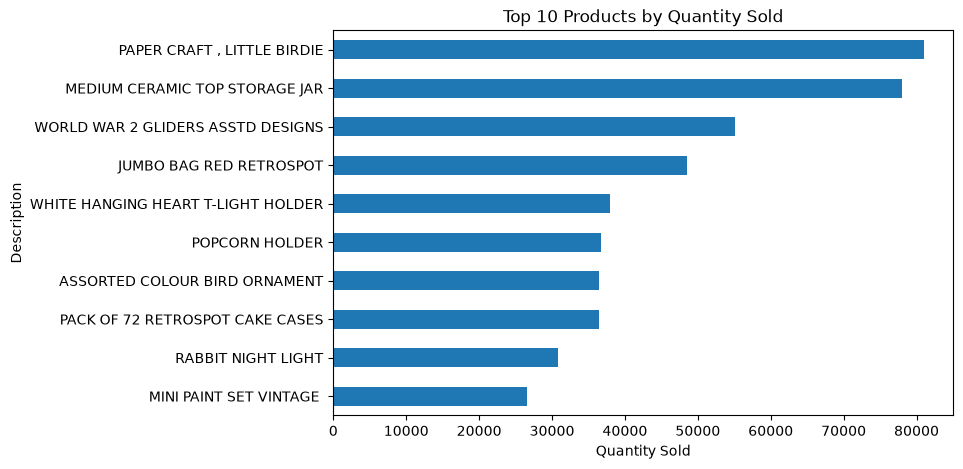

In [42]:
top_products = retail_df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
print(top_products)

import matplotlib.pyplot as plt
top_products.plot(kind='barh', figsize=(8,5))
plt.title('Top 10 Products by Quantity Sold')
plt.xlabel('Quantity Sold')
plt.gca().invert_yaxis()
plt.show()

2. Highest revenue-generating countries


Country
United Kingdom    9003097.964
Netherlands        285446.340
EIRE               283453.960
Germany            228867.140
France             209715.110
Australia          138521.310
Spain               61577.110
Switzerland         57089.900
Belgium             41196.340
Sweden              38378.330
Name: Revenue, dtype: float64


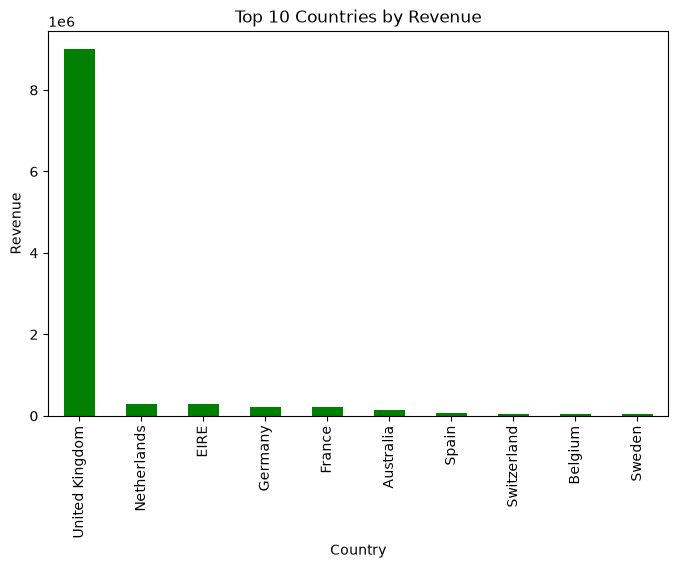

In [43]:
top_countries = retail_df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)
print(top_countries)

top_countries.plot(kind='bar', figsize=(8,5), color='green')
plt.title('Top 10 Countries by Revenue')
plt.ylabel('Revenue')
plt.show()

3. Monthly sales trends


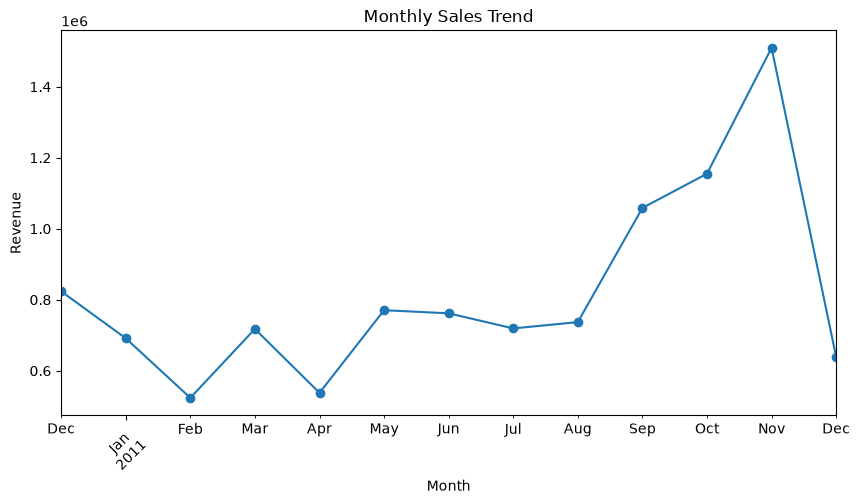

In [44]:
retail_df['Month'] = retail_df['InvoiceDate'].dt.to_period('M')
monthly_sales = retail_df.groupby('Month')['Revenue'].sum()

monthly_sales.plot(kind='line', marker='o', figsize=(10,5))
plt.title('Monthly Sales Trend')
plt.ylabel('Revenue')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.show()

4. Most purchased products (by number of orders/transactions, not just quantity)


Description
WHITE HANGING HEART T-LIGHT HOLDER    2260
JUMBO BAG RED RETROSPOT               2092
REGENCY CAKESTAND 3 TIER              1989
PARTY BUNTING                         1686
LUNCH BAG RED RETROSPOT               1564
ASSORTED COLOUR BIRD ORNAMENT         1455
SET OF 3 CAKE TINS PANTRY DESIGN      1385
PACK OF 72 RETROSPOT CAKE CASES       1320
LUNCH BAG  BLACK SKULL.               1273
NATURAL SLATE HEART CHALKBOARD        1249
Name: InvoiceNo, dtype: int64


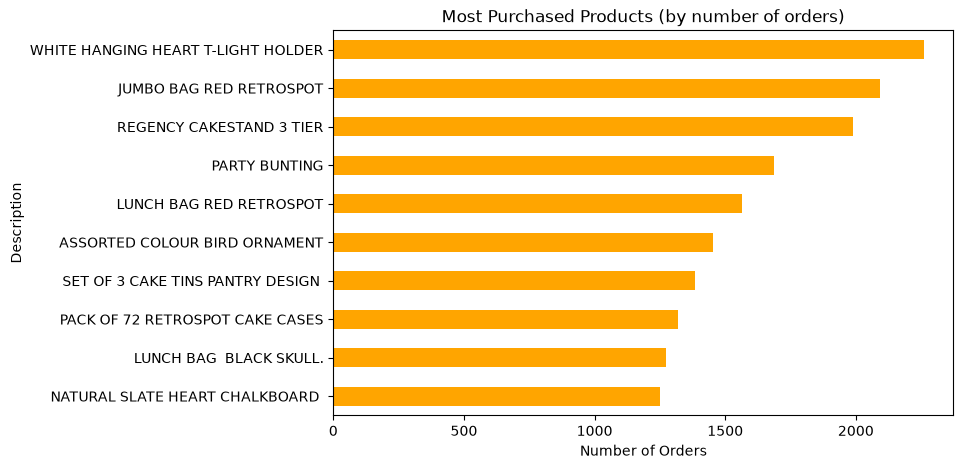

In [45]:
most_purchased = retail_df.groupby('Description')['InvoiceNo'].nunique().sort_values(ascending=False).head(10)
print(most_purchased)

most_purchased.plot(kind='barh', figsize=(8,5), color='orange')
plt.title('Most Purchased Products (by number of orders)')
plt.xlabel('Number of Orders')
plt.gca().invert_yaxis()
plt.show()

5. Customer purchasing behavior


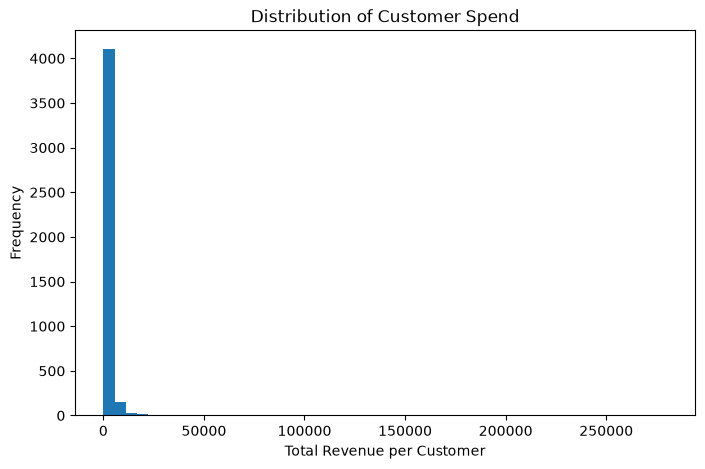

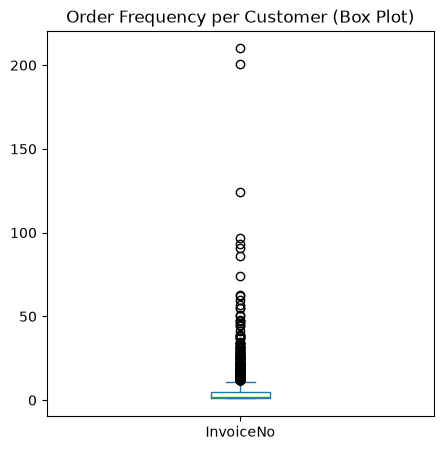

In [46]:
# Total spend per customer
customer_spend = retail_df.groupby('CustomerID')['Revenue'].sum()

# Distribution of customer spend
customer_spend.plot(kind='hist', bins=50, figsize=(8,5))
plt.title('Distribution of Customer Spend')
plt.xlabel('Total Revenue per Customer')
plt.show()

# Distribution of order frequency (how many invoices per customer)
customer_orders = retail_df.groupby('CustomerID')['InvoiceNo'].nunique()
customer_orders.plot(kind='box', figsize=(5,5))
plt.title('Order Frequency per Customer (Box Plot)')
plt.show()